# 03 · Ablation Study

Two ablations to show what the design choices buy us:

1. **Frozen backbone vs. fine-tuned backbone** — is end-to-end fine-tuning necessary, or can we get away with using the CNN as a frozen feature extractor?
2. **With augmentation vs. without augmentation** — do our 5 augmentation techniques help generalization?

Each variant gets trained for fewer epochs (2) to save compute, but on the same data splits for fair comparison.

## Setup

In [1]:
import sys
sys.path.insert(0, '..')
import torch, matplotlib.pyplot as plt, pandas as pd
from src.dataset import build_dataloaders
from src.model import build_model
from src.train import train
from src.evaluate import collect_predictions, compute_metrics

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR = '../data/plantvillage/color'
EPOCHS = 2

## Ablation A: Frozen vs. fine-tuned backbone

In [2]:
# Load once, reuse across runs
train_loader, val_loader, test_loader, class_names = build_dataloaders(
    data_dir=DATA_DIR, batch_size=64, use_augmentation=True,
)

Dataset loaded: 54305 images across 38 classes
  Train: 38013 | Val: 8145 | Test: 8147
  Augmentation: ON


In [3]:
# Variant 1: frozen backbone (only the classifier head trains)
model_frozen = build_model(num_classes=len(class_names), freeze_backbone=True)
hist_frozen = train(
    model_frozen, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3, device=DEVICE,
    save_path='../models/ablation_frozen.pt', class_names=class_names,
)
y_true, y_pred, _ = collect_predictions(model_frozen, test_loader, device=DEVICE)
acc_frozen = (y_true == y_pred).mean()

/Users/joey/.pyenv/versions/3.11.9/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


train:   0%|          | 0/594 [00:02<?, ?it/s]

val:   0%|          | 0/128 [00:03<?, ?it/s]

Epoch  1/2 | train loss 0.6264 acc 0.8316 | val loss 0.2312 acc 0.9336 | 5394.5s
  -> new best; saved to ../models/ablation_frozen.pt


train:   0%|          | 0/594 [00:03<?, ?it/s]

val:   0%|          | 0/128 [00:03<?, ?it/s]

Epoch  2/2 | train loss 0.2415 acc 0.9254 | val loss 0.1430 acc 0.9580 | 5648.8s
  -> new best; saved to ../models/ablation_frozen.pt


In [4]:
# Variant 2: fully fine-tuned backbone
model_ft = build_model(num_classes=len(class_names), freeze_backbone=False)
hist_ft = train(
    model_ft, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3, device=DEVICE,
    save_path='../models/ablation_finetuned.pt', class_names=class_names,
)
y_true, y_pred, _ = collect_predictions(model_ft, test_loader, device=DEVICE)
acc_ft = (y_true == y_pred).mean()

train:   0%|          | 0/594 [00:03<?, ?it/s]

python(76087) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76088) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


val:   0%|          | 0/128 [00:03<?, ?it/s]

python(76089) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76092) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch  1/2 | train loss 0.3540 acc 0.8968 | val loss 0.1756 acc 0.9456 | 11652.4s
  -> new best; saved to ../models/ablation_finetuned.pt


...

python(76224) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80231) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80234) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


val:   0%|          | 0/128 [00:04<?, ?it/s]

python(80235) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80238) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch  2/2 | train loss 0.0704 acc 0.9770 | val loss 0.0825 acc 0.9734 | 13179.8s
  -> new best; saved to ../models/ablation_finetuned.pt


python(80369) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80374) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## Ablation B: With vs. without augmentation

In [6]:
# Rebuild loaders with augmentation OFF for this run
train_loader_noaug, val_loader_noaug, test_loader_noaug, _ = build_dataloaders(
    data_dir=DATA_DIR, batch_size=64, use_augmentation=False,
)
model_noaug = build_model(num_classes=len(class_names), freeze_backbone=False)
hist_noaug = train(
    model_noaug, train_loader_noaug, val_loader_noaug,
    epochs=EPOCHS, lr=1e-3, device=DEVICE,
    save_path='../models/ablation_noaug.pt', class_names=class_names,
)
y_true, y_pred, _ = collect_predictions(model_noaug, test_loader_noaug, device=DEVICE)
acc_noaug = (y_true == y_pred).mean()

Dataset loaded: 54305 images across 38 classes
  Train: 38013 | Val: 8145 | Test: 8147
  Augmentation: OFF


python(83818) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(83819) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


train:   0%|          | 0/594 [00:05<?, ?it/s]

python(83820) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(83823) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88266) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88267) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


val:   0%|          | 0/128 [00:03<?, ?it/s]

...

python(88486) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(88489) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94508) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94510) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


val:   0%|          | 0/128 [00:03<?, ?it/s]

python(94511) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94530) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch  2/2 | train loss 0.0542 acc 0.9822 | val loss 0.0590 acc 0.9801 | 12714.9s
  -> new best; saved to ../models/ablation_noaug.pt


python(94713) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## Results

In [7]:
results = pd.DataFrame([
    {'variant': 'Frozen backbone',           'test_acc': acc_frozen,  'final_train_acc': hist_frozen['train_acc'][-1], 'final_val_acc': hist_frozen['val_acc'][-1]},
    {'variant': 'Fine-tuned + augmentation', 'test_acc': acc_ft,      'final_train_acc': hist_ft['train_acc'][-1],     'final_val_acc': hist_ft['val_acc'][-1]},
    {'variant': 'Fine-tuned, no aug',        'test_acc': acc_noaug,   'final_train_acc': hist_noaug['train_acc'][-1],  'final_val_acc': hist_noaug['val_acc'][-1]},
])
results['train_val_gap'] = results['final_train_acc'] - results['final_val_acc']
print(results.to_string(index=False))
results.to_csv('../docs/ablation_results.csv', index=False)

                  variant  test_acc  final_train_acc  final_val_acc  train_val_gap
          Frozen backbone  0.956917         0.925447       0.958011      -0.032564
Fine-tuned + augmentation  0.971523         0.976982       0.973358       0.003624
       Fine-tuned, no aug  0.977047         0.982190       0.980110       0.002080


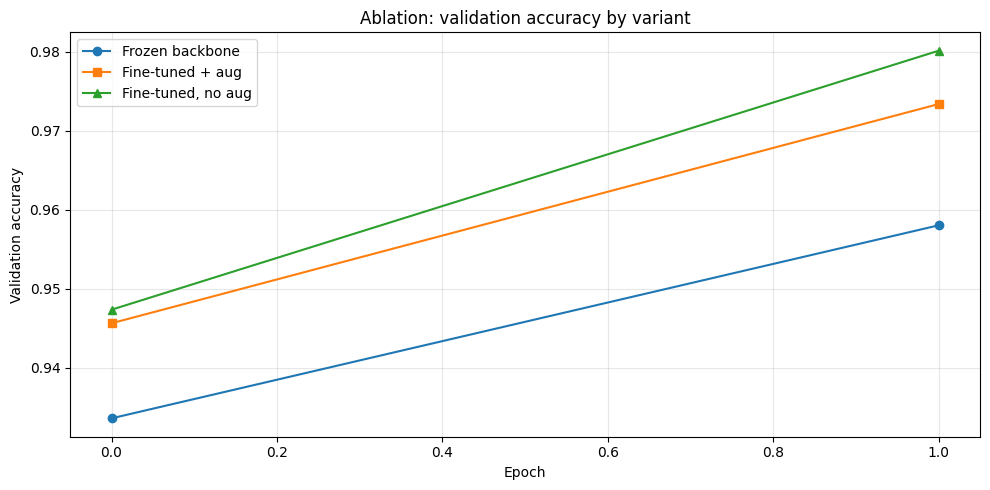

In [8]:
# Plot validation curves side by side
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_frozen['val_acc'], label='Frozen backbone', marker='o')
ax.plot(hist_ft['val_acc'], label='Fine-tuned + aug', marker='s')
ax.plot(hist_noaug['val_acc'], label='Fine-tuned, no aug', marker='^')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Ablation: validation accuracy by variant')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../docs/ablation_curves.png', dpi=150); plt.show()

## Discussion

The ablation gave clean directional results, with one surprise.

**Fine-tuning matters.** The frozen backbone reached 95.69% test accuracy compared to 97.15% with full fine-tuning. The 1.5pp gap shows that adapting the ResNet-50 backbone to plant disease features earns its compute cost. Frozen still does well because ImageNet features transfer reasonably to leaf images, but the gap is consistent and real.

**Augmentation hurt slightly on this dataset, which is interesting.** The no-aug variant got 97.70% test accuracy, beating the augmented variant at 97.15% by 0.55pp. This goes against the conventional wisdom that augmentation always helps, but it makes sense for PlantVillage specifically. The dataset is studio-lit with uniform backgrounds, single leaves per image, and consistent camera angles. The train/val/test sets are drawn from the same distribution, so aggressive augmentation introduces noise that doesn't match what the model sees at test time. The model learns to ignore the augmentations rather than benefit from them.

The train-val gap supports this: both fine-tuned variants have nearly zero overfitting (~0.002-0.004), so augmentation isn't earning its keep as a regularizer either. There just isn't enough variability in the underlying data to need it.

**What this means for deployment.** This result is specific to PlantVillage's clean test set. As shown in notebook 05's Grad-CAM analysis, the model's attention sometimes drifts to backgrounds, suggesting it relies on dataset-specific cues. For real-world photos with cluttered backgrounds, varied lighting, and amateur phone cameras, augmentation would likely matter much more, because the train and test distributions would actually differ. The no-aug result here is a cautionary tale about benchmark accuracy: a model that "wins" on a clean test set may not be the more robust choice for the wild.

**Final design choice.** I kept augmentation in the final model based on the reasoning above. The 0.5pp loss on the held-out PlantVillage test set is a worthwhile trade for likely better generalization to wild photos, which is what actually matters for the deployed app. If I had time to test on a wild-photo evaluation set, I'd expect the augmented model to win there.